## Calculate the Lyapunov spectrum of ECA rule 150

### _Tracing a single defect_
The Jacobian associated with an ECA of $N$ cells governed by rule 150 is
$$
\mathbf{J}(\vec{x}^t) = \mathbf{J} = \begin{pmatrix}
1 & 1 & 0 & \ldots & 0 & 0 & 1 \\
1 & 1 & 1 & \ldots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \ldots & 1 & 1 & 1 \\
1 & 0 & 0 & \ldots & 0 & 1 & 1
\end{pmatrix}.
$$
A single perturbation in cell $i=1$ is written as
$$
\delta\vec{x}_1 = \begin{pmatrix}
1\\
0\\
\vdots \\
0
\end{pmatrix},
$$
so the propagation of this perturbation in tangent space is
$$
\delta \vec{x}^t_1 = \mathbf{J}^t \delta\vec{x}_1.
$$
This column vector can be plotted in its entirety to show how many times each cell has been affected, in what is known as the _Lyapunov profile_. However, the _relevant_ Lyapunov exponent is simply the normalised logarithm of the maximal value of this column vector, i.e.
$$
\lambda_i = \lim_{t\rightarrow\infty}\frac{1}{t}\ln\left({\max_j\{\left(\mathbf{J}^t \delta\vec{x}_i\right)_j\}}\right).
$$
This value indicates the largest possible growth in defect due to an initial perturbation. There may be other places where the defect has an impact, but only the largest value will determine whether a system is chaotic or not.

### _Tracing all unit defects simultaneously_

One could iteratively calculate the Lyapunov exponent $\lambda_i$ for each defect $\delta\vec{x}_i$ individually, but that is algebraically identical to just appending all initial defects together in what you could call a perturbation sphere $\mathbf{Y}^0$:
$$
\mathbf{Y}^0 = \begin{pmatrix}
\delta\vec{x}_1 & \delta\vec{x}_2 & \cdots & \delta\vec{x}_N
\end{pmatrix}  = \mathbf{I}_N,
$$
the unit diagonal matrix (identity matrix). For rule 150, this again results in $\mathbf{Y}^t = \mathbf{J}^t \mathbf{Y}^0$. The set of Lyapunov exponents is than simply related to the maximum in each column of $\mathbf{Y}^t$.

### _Tracing the perturbation sphere_

We can also trace all defects at the same time, but in a slightly more sophisticated way that arguably has a better geometric interpretation.

We are now interested in the _singular values_ of matrix $Y^t$, which is identical to the positive roots of the eigenvalues of the positive definite matrix $\Gamma^t = Y^t \times (Y^t)^T$. The singular values of $Y^t$ are geometrically interpreted as the lengths of the semi-axes of the ellipsoid represented by $Y^t$ (evolved from the initial unit sphere $Y^0$). The corresponding singular vectors represent the directions of this ellipsoid's axes (but we will not go into that here). So:
$$
\Gamma^t \vec{v}_i = \sigma_i^2 \vec{v}_i
$$
for $i \in \{1, \ldots, N\}$. Note again that $\sigma_i^2$ will indeed always be positive, because $\Gamma$ has been constructed to be positive definite. The final step is then to just plot the distribution of all $\{\sigma_i\}$, quantifying how the unit sphere is being stretched. The Lyapunov exponent are then defined as
$$
\lambda_i = \lim_{t\rightarrow\infty}\frac{1}{t}\ln{\sigma_i} = \lim_{t\rightarrow\infty}\frac{1}{2t}\ln{\sigma_i^2}
$$
Note also that, if the Jacobian is symmetric (as is the case for rule 150), the singular values are identical to the absolute values of the eigenvalues of $\mathbf{J}$.

We now look at the various interpretations, and apply it to a number of ECAs.

In [12]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.datasets import NetworksDataset
from src.automata import LLNA
from src.simulation import *
from src.analysis import jacobian, defect_diameter, calculate_Yt, lyapunov_spectrum

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# The Lyapunov profile

In [13]:
# number of cells
N = 1001

# define Jacobian
# main diagonal
J = np.diag(np.ones(N, dtype=np.float64))
# lower and upper diagonals
J += np.diag(np.ones(N-1, dtype=np.float64), k=1)
J += np.diag(np.ones(N-1, dtype=np.float64), k=-1)
J_nonperiodic = J.copy()
# corner elements
J[0, N-1] = 1
J[N-1, 0] = 1

defect_id = N//2
delta_xi = np.zeros(N, dtype=np.float64)
delta_xi[defect_id] = 1

T = N//2
ts = np.arange(1,T)
tangent_defects = []
lambdas_i = []

Jt = J.copy()
cutoff=1
for t in ts:
    # update defect
    print(f"t={t}", end='\r')
    tangent_defect = Jt.dot(delta_xi)
    lambda_i = np.log(np.max(tangent_defect)) / t
    lambdas_i += [lambda_i]
    tangent_defects += [tangent_defect]
    Jt = J.dot(Jt)

Text(0.5, 1.0, 'Normalised Lyapunov profile')

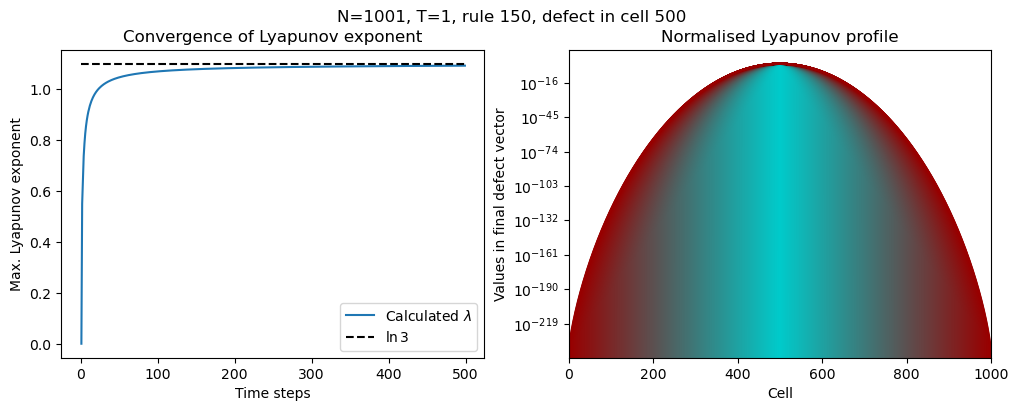

In [4]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))

ax1.plot(ts, lambdas_i, label=f'Calculated $\\lambda$')
ax1.plot([0, np.max(ts)], [np.log(3), np.log(3)], 'k--', label=f'$\ln{3}$')
ax1.legend()
ax1.set_ylabel("Max. Lyapunov exponent")
ax1.set_xlabel("Time steps")

start_color = np.array([0, 204, 204])
end_color = np.array([153, 0, 0])

# Generate gradient
gradient = np.linspace(start_color, end_color, T)
gradient = gradient.astype(int)  # Convert to integer values

# Convert to hex format
gradient_hex = ['#%02x%02x%02x' % tuple(color) for color in gradient]

for j, td in enumerate(np.array(tangent_defects)[:-1]):
    ax2.plot(td/np.max(td), c=gradient_hex[j])
    ax2.set_yscale('log')
    ax2.set_ylabel("Values in final defect vector")
    ax2.set_xlabel("Cell")
    ax2.set_xlim([0, N])

fig.suptitle(f"N={N}, T={cutoff}, rule 150, defect in cell {defect_id}")
ax1.set_title("Convergence of Lyapunov exponent")
ax2.set_title("Normalised Lyapunov profile")

**Interpretation of the figures above**

In the figure on the lefthand side, we find the value of $\lambda_i = \lim_{t\rightarrow\infty}\frac{1}{t}\ln\left({\max_j\{\left(\mathbf{J}^t \delta\vec{x}_i\right)_j\}}\right)$, i.e. the normalised logarithm of the largest defect in tangent space after introducing a defect in node $i$. As the largest element can be shown to approach $3^t$ when $t\rightarrow\infty$, we see the asymptotic approach to the value $\ln{3}$.

In the figure on the righthand side, we observe the final state of all element in the vector $\delta\vec{x}^t$. On the $y$ axis, we find the normalised number of defects in tangent space, logarithmically spaced. On the $x$ axis are the cells in our ECA. Clearly this is symmetric around cell with index $i=500$, because this is where the original defect was introduced. We show the Lyapunov profile for ever-increasing values of $T$.

# Lyapunov spectrum

In the second interpretation, we consider the (simultaneous) evolution of all possible single-cell defects by tracing the eigenvalues of the matrix $\Gamma^t = Y^t(Y^t)^T$.

In [8]:
# number of cells
N = 1001

# define Jacobian for rule 150
# main diagonal
J = np.diag(np.ones(N, dtype=np.float64))
# lower and upper diagonals
J += np.diag(np.ones(N-1, dtype=np.float64), k=1)
J += np.diag(np.ones(N-1, dtype=np.float64), k=-1)
J_nonperiodic = J.copy()
# corner elements
J[0, N-1] = 1
J[N-1, 0] = 1

defect_id = N//2
delta_xi = np.zeros(N, dtype=np.float64)
delta_xi[defect_id] = 1

T = N//4
ts = np.arange(1,T)
tangent_defects = []
lambdas_i = []

Jt = J.copy()
Gammat = Jt.dot(Jt.T)
for t in ts:
    print(f"t={t}", end='\r')
    # find eigenvalues
    eigvalsh = np.linalg.eigvalsh(Gammat)
    lambdas = np.log(eigvalsh)/(2*t)
    lambdas_i += [lambdas[~np.isnan(lambdas)]]
    # update defect
    Jt = J.dot(Jt)
    Gammat = Jt.dot(Jt.T)
    if np.isnan(Gammat).any():
        raise Exception("Overflow!")
    
max_lambdas = [np.max(lambda_i) for lambda_i in lambdas_i]

C:\Users\mrollier\AppData\Local\Temp\ipykernel_13616\1630295911.py:30: RuntimeWarning: invalid value encountered in log
  lambdas = np.log(eigvalsh)/(2*t)


Text(0.5, 1.0, 'Normalised Lyapunov profile')

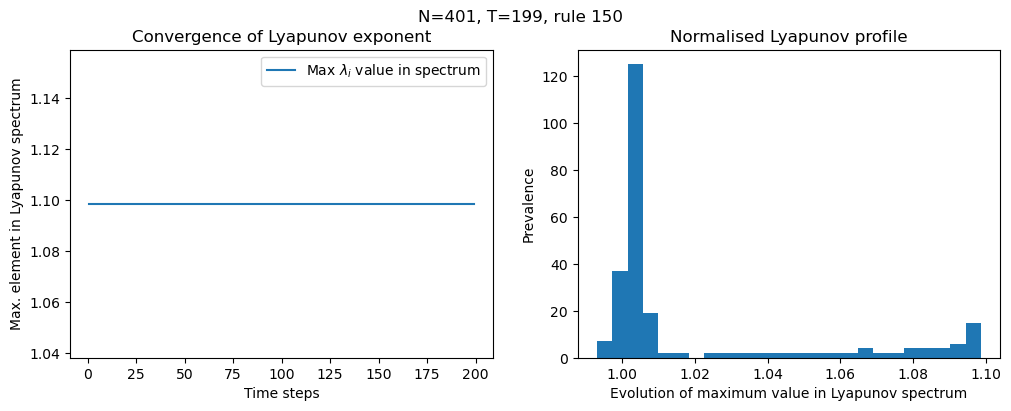

In [11]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))

ax1.plot(ts, max_lambdas, label=f'Max $\\lambda_i$ value in spectrum')
ax1.legend()
ax1.set_ylabel("Max. element in Lyapunov spectrum")
ax1.set_xlabel("Time steps")

ax2.hist(lambdas_i[-1], bins=25)
ax2.set_ylabel("Prevalence")
ax2.set_xlabel("Evolution of maximum value in Lyapunov spectrum")

fig.suptitle(f"N={N}, T={ts[-1]}, rule 150")
ax1.set_title("Convergence of Lyapunov exponent")
ax2.set_title("Normalised Lyapunov profile")

Text(0.5, 1.0, 'spread of eigenvalues of $N=11$ Jacobian\nwith or without corner elements')

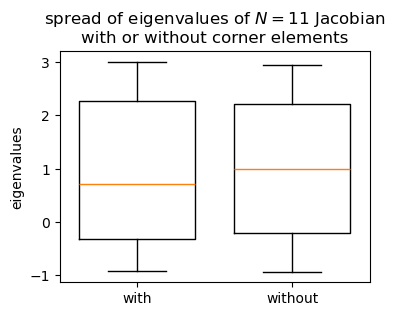

In [2]:
# calculate eigenvalues
eigvals = np.linalg.eigvals(J)
eigvals_nonperiodic= np.linalg.eigvals(J_nonperiodic)

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.boxplot([eigvals, eigvals_nonperiodic], widths=.75)
ax.set_xticklabels(['with', 'without'])
ax.set_ylabel(f"eigenvalues")
ax.set_title(f"spread of eigenvalues of $N={N}$ Jacobian\nwith or without corner elements")

*Note* that the corner elements (which support the periodicity of the CA) have an important impact on the spread of the eigenvalues! In their absence, the spread of the eigenvalues is independent of the matrix size. Otherwise, it asymptotically approaches that spread for $N \rightarrow \infty$.

Now, from these eigenvalues we should be able to find the Lyapunov spectrum. Let us try it slightly different than with our previous definitions - now using Wikipedia. Say $\Gamma = Y(t) \times Y(t)^T$. This makes $\Gamma$ symmetric and positive semi-definite. Let us define the matrix
$$
\Lambda = \lim_{t\rightarrow\infty}\frac{1}{2t}\ln\left(\mathbf{Y}(t)\mathbf{Y}(t)^T\right) = \lim_{t\rightarrow\infty}\frac{1}{2t}\ln\left(\mathbf{\Gamma}\right),
$$
where the natural logarithm is applied element-wise. Then the $N$ eigenvalues $\{\lambda_i\}$ of $\Lambda$ are precisely the Lyapunov exponents. Note two things:
1. There are certainly $N$ real-valued eigenvalues, because $\mathbf{\Gamma}$ is symmetric and real-valued.
2. The limit only exists because of the Oseledet's theorem (**QUESTION** not sure what this is).
3. **Problem** some elements in $\Gamma$ may be zero, so the element-wise logarithm works out to minus infinity, which is problematic when calculating the eigenvalues. Note that the eigenvalues _cannot_ be negative, because the matrix is positive semi-definite.
4. **Problem** the order of operations is important, of course! First applying the logarithm, or first finding the eigenvalues makes a big difference. Both definitions are used in Milan's paper, but I don't think that makes a whole lot of sense. in the code he uses the definition where first the eigenvalues are calculated (makes more sense I guess?).
5. ...

In [84]:
Jt.dot(Jt.T)
# print(np.linalg.eigvalsh(Jt.dot(Jt.T)))

array([[inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf],
       ...,
       [inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf]])

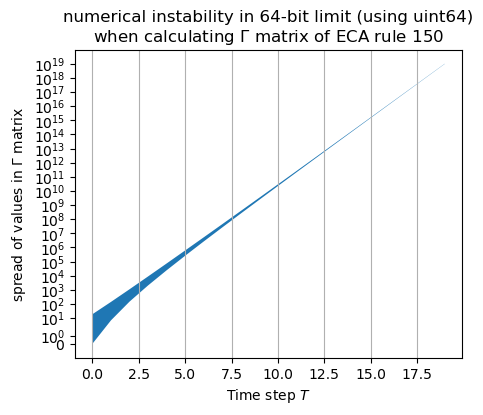

In [5]:
Gamma_mins = []
Gamma_maxs = []
Ts = np.arange(0, 20)
J_t = J.copy()
for T in Ts:
    print(T, end='\r')
    # NOTE this becomes expensive for high values of N
    J_t = np.matmul(J, J_t)
    Gamma = np.matmul(J_t, J_t.T)
    Gamma_min = np.min(Gamma)
    Gamma_max = np.max(Gamma)
    Gamma_maxs += [Gamma_max]
    Gamma_mins += [Gamma_min]

fig, ax = plt.subplots(1,1,figsize=(5,4))

ax.fill_between(Ts, Gamma_mins, Gamma_maxs)
# plt.plot(Ts, Gamma_mins)
ax.set_yscale('symlog')
ax.set_title("numerical instability in 64-bit limit (using uint64)\nwhen calculating $\\Gamma$ matrix of ECA rule 150")
# plt.ylabel("minimum value in $\\Gamma$ matrix")
ax.set_ylabel("spread of values in $\\Gamma$ matrix")
ax.set_xlabel("Time step $T$")
ax.xaxis.grid()

Clearly there is numerical instability after about 20 time steps, so this **will have to be addressed!** One way would be to make use of the `mpmath` Python package.

18446744073709551616

In [63]:
J.dot(J) == np.linalg.matrix_power(J, 2)

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [67]:
# current max T value before numerical breakdown is 20 (but that is dependent on set-up)
T = 4
J_t = np.linalg.matrix_power(J, T)
Gamma = np.matmul(J_t, J_t.T)

print(np.max(Gamma))

Lambdas = np.log(Gamma)/(2*T)
lambdas, = np.linalg.eig(Lambdas)

_=plt.hist(lambdas, bins=100)

1107


C:\Users\mrollier\AppData\Local\Temp\ipykernel_9800\2149084753.py:8: RuntimeWarning: divide by zero encountered in log
  Lambdas = np.log(Gamma)/(2*T)


LinAlgError: Array must not contain infs or NaNs

## Milan's code

In [ ]:
### This file is made by Milan Vispoel

# %% imports

import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from numpy import linalg as LA

def matrix_j(rule, parameters):
    #compute the product of Jacobians
    graph = nx.connected_watts_strogatz_graph(nodes, k, p_rewire, tries = 100, seed=None)
    states = cellular_automaton(graph, rule_90_150, parameters, ts)
    jac = jacobian(states[0], rule, parameters, graph)
    for t in range(1,ts):
        # NOTE: why is this states[ts]? According to equation (9) it should be states[t]
        jac = jacobian(states[ts], rule, parameters, graph).dot(jac)
    return jac

def lyapunov(rule, parameters):
    y_mat = matrix_j(rule, parameters)
    # NOTE: so here we first take the eigenvalues, and only take their logarithm afterwards
    w, v = LA.eig(y_mat*y_mat.T)
    return w

def lyapunov_average(rule, parameters, iterations):
    #compute the spectrum over a number of iterations to get statistically relevant results
    result = []
    for i in range(iterations):
        temp = lyapunov(rule, parameters)
        result.append(abs(temp))
        print(i)
    return result

def remove_z(arr):
    return arr[arr != 0]

# %% Executions and plot

eigenvalues = lyapunov_average(rule_90_150, parameters, iterations)
eigenvalues = np.sort((np.array(eigenvalues)).flatten())
# NOTE: why are we sure there are no negative eigenvalues?
spectrum = (1/(2*ts))*np.log(remove_z(eigenvalues))


#Plot spectrum in histogram
bin_count=50
normalized = False

if len(spectrum) > 0:
    plt.rcParams["figure.figsize"] = (12,8)
    plt.rcParams.update({'font.size': 20})
    N, bins, patches = plt.hist(spectrum, bins=bin_count, density=True, alpha=0.5, histtype='bar', ec='black')
    if normalized == True:
        plt.xlim(0,1)
    plt.xlabel("$\lambda$")
    plt.ylabel(r"$\rho(\lambda)$")
    plt.show()
# %%
